# 22 Randomized Robustness Figures

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "22_randomized_robustness_figures"
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / "figures"
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / "tables"
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / "data"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENDER_ORDER = ["MM", "MW", "WM", "WW"]

draw = pd.read_csv(
    PROJECT_ROOT
    / "outputs"
    / "18_randomized_drawing_baseline_weighted"
    / "tables"
    / "randomized_reference_drawing_oe_by_gender.csv"
)

network = pd.read_csv(
    PROJECT_ROOT
    / "outputs"
    / "19_network_conditioned_edge_randomization"
    / "tables"
    / "network_conditioned_edge_randomization_oe_by_gender.csv"
)

bc_prior = pd.read_csv(
    PROJECT_ROOT
    / "outputs"
    / "20_bib_coupling_edge_randomization_prior_weighted"
    / "tables"
    / "bib_coupling_prior_weighted_randomization_oe_by_gender.csv"
)

## Randomized Reference Drawing

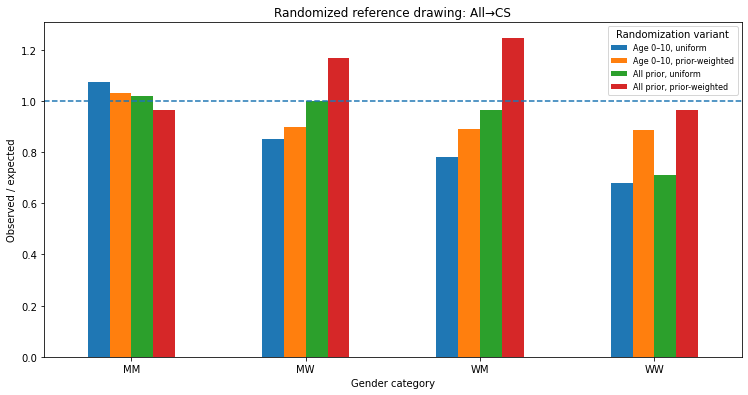

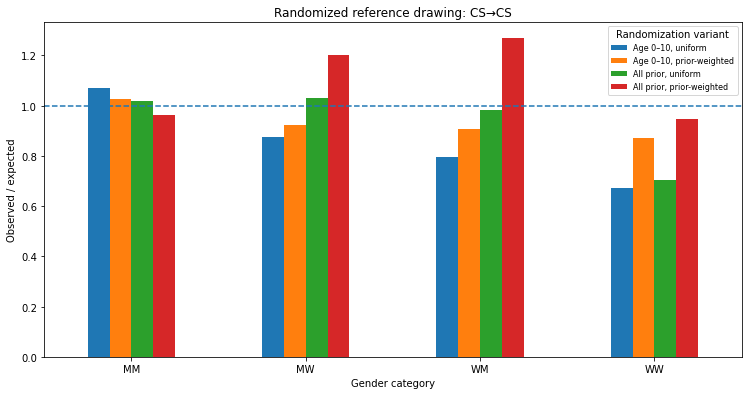

,"Age 0–10, uniform","Age 0–10, prior-weighted","All prior, uniform","All prior, prior-weighted"
gender_cat,,,,
MM,1.073844,1.031148,1.021262,0.966417
MW,0.850343,0.896824,1.001820,1.167744
WM,0.780203,0.891625,0.965739,1.245645
WW,0.681070,0.886271,0.712472,0.963031


,"Age 0–10, uniform","Age 0–10, prior-weighted","All prior, uniform","All prior, prior-weighted"
gender_cat,,,,
MM,1.068573,1.026991,1.016916,0.962960
MW,0.874123,0.920610,1.030157,1.200596
WM,0.794839,0.907062,0.983789,1.268157
WW,0.672106,0.872183,0.702052,0.946829


In [2]:
DRAW_VARIANTS = [
    ("age_0_10", "uniform", "Age 0–10, uniform"),
    ("age_0_10", "prior_weighted", "Age 0–10, prior-weighted"),
    ("all_prior", "uniform", "All prior, uniform"),
    ("all_prior", "prior_weighted", "All prior, prior-weighted"),
]

def randomized_drawing_plot(citation_slice, filename):
    z = draw[draw["citation_slice"].eq(citation_slice)].copy()
    series = {}

    for eligibility, scheme, label in DRAW_VARIANTS:
        q = z[
            z["eligibility_rule"].eq(eligibility)
            & z["drawing_scheme"].eq(scheme)
        ].copy()

        q["gender_cat"] = pd.Categorical(
            q["gender_cat"],
            categories=GENDER_ORDER,
            ordered=True,
        )
        q = q.sort_values("gender_cat")
        series[label] = q.set_index("gender_cat")["oe_ratio"]

    plot_df = pd.DataFrame(series).reindex(GENDER_ORDER)

    ax = plot_df.plot(kind="bar", figsize=(10.5, 5.6))
    ax.axhline(1, linestyle="--")
    ax.set_xlabel("Gender category")
    ax.set_ylabel("Observed / expected")
    ax.set_title(f"Randomized reference drawing: {citation_slice}")
    ax.legend(title="Randomization variant", fontsize=8)
    plt.xticks(rotation=0)
    plt.tight_layout()

    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

    return plot_df

draw_all = randomized_drawing_plot(
    "All→CS",
    "randomized_reference_drawing_oe_all_to_cs.png",
)
draw_cs = randomized_drawing_plot(
    "CS→CS",
    "randomized_reference_drawing_oe_cs_to_cs.png",
)

display(draw_all)
display(draw_cs)

## Network-Conditioned Edge Randomization

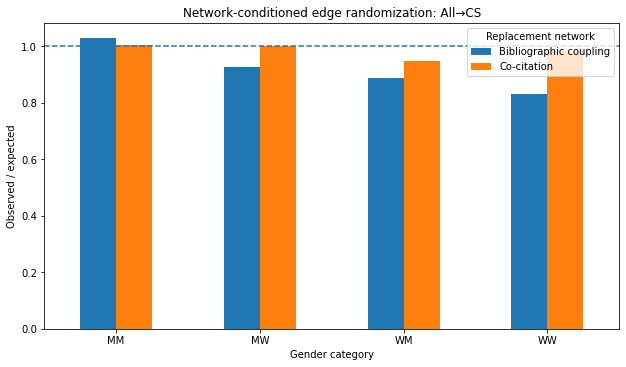

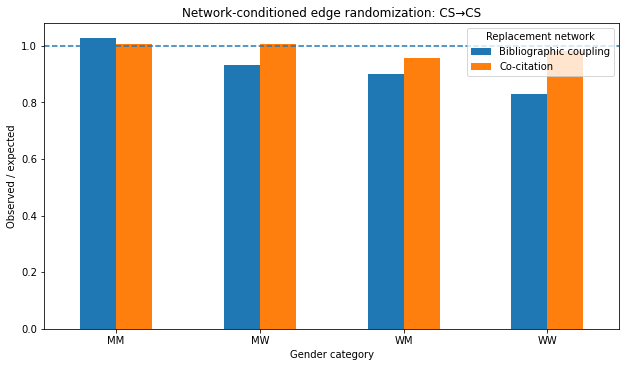

,Bibliographic coupling,Co-citation
gender_cat,,
MM,1.031252,1.006167
MW,0.926721,0.999978
WM,0.887275,0.949292
WW,0.832259,0.982095


,Bibliographic coupling,Co-citation
gender_cat,,
MM,1.029233,1.005094
MW,0.933549,1.005973
WM,0.898698,0.955355
WW,0.830115,0.981094


In [3]:
NETWORK_LABELS = {
    "network_randomization_bibliographic_coupling": "Bibliographic coupling",
    "network_randomization_cocitation": "Co-citation",
}

def network_randomization_plot(citation_slice, filename):
    z = network[network["citation_slice"].eq(citation_slice)].copy()
    series = {}

    for baseline, label in NETWORK_LABELS.items():
        q = z[z["baseline"].eq(baseline)].copy()
        q["gender_cat"] = pd.Categorical(
            q["gender_cat"],
            categories=GENDER_ORDER,
            ordered=True,
        )
        q = q.sort_values("gender_cat")
        series[label] = q.set_index("gender_cat")["oe_ratio"]

    plot_df = pd.DataFrame(series).reindex(GENDER_ORDER)

    ax = plot_df.plot(kind="bar", figsize=(8.8, 5.2))
    ax.axhline(1, linestyle="--")
    ax.set_xlabel("Gender category")
    ax.set_ylabel("Observed / expected")
    ax.set_title(f"Network-conditioned edge randomization: {citation_slice}")
    ax.legend(title="Replacement network")
    plt.xticks(rotation=0)
    plt.tight_layout()

    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

    return plot_df

network_all = network_randomization_plot(
    "All→CS",
    "network_conditioned_randomization_oe_all_to_cs.png",
)
network_cs = network_randomization_plot(
    "CS→CS",
    "network_conditioned_randomization_oe_cs_to_cs.png",
)

display(network_all)
display(network_cs)

## Randomization Coverage

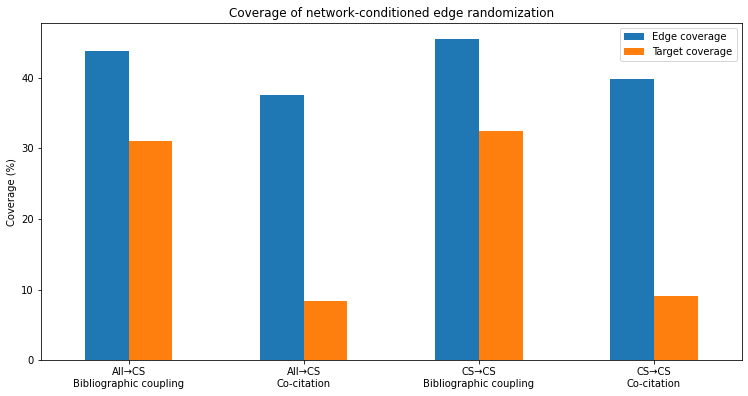

,citation_slice,network,replaceable_edges,edge_coverage,replaceable_targets,target_coverage
0,All→CS,Bibliographic coupling,3801614,0.437659,219703,0.310290
4,All→CS,Co-citation,3258437,0.375126,58866,0.083137
8,CS→CS,Bibliographic coupling,3192648,0.454567,209348,0.324233
12,CS→CS,Co-citation,2795004,0.397950,58812,0.091086


In [4]:
coverage = (
    network[
        [
            "citation_slice",
            "baseline",
            "replaceable_edges",
            "edge_coverage",
            "replaceable_targets",
            "target_coverage",
        ]
    ]
    .drop_duplicates()
    .copy()
)

coverage["network"] = coverage["baseline"].map(NETWORK_LABELS)
coverage["configuration"] = (
    coverage["citation_slice"].astype(str)
    + "\n"
    + coverage["network"].astype(str)
)
coverage["Edge coverage"] = 100 * coverage["edge_coverage"]
coverage["Target coverage"] = 100 * coverage["target_coverage"]

coverage_order = [
    "All→CS\nBibliographic coupling",
    "All→CS\nCo-citation",
    "CS→CS\nBibliographic coupling",
    "CS→CS\nCo-citation",
]

coverage["configuration"] = pd.Categorical(
    coverage["configuration"],
    categories=coverage_order,
    ordered=True,
)
coverage = coverage.sort_values("configuration")

plot_df = (
    coverage.set_index("configuration")[
        ["Edge coverage", "Target coverage"]
    ]
    .reindex(coverage_order)
)

ax = plot_df.plot(kind="bar", figsize=(10.5, 5.6))
ax.set_xlabel("")
ax.set_ylabel("Coverage (%)")
ax.set_title("Coverage of network-conditioned edge randomization")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "network_randomization_coverage.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

display(
    coverage[
        [
            "citation_slice",
            "network",
            "replaceable_edges",
            "edge_coverage",
            "replaceable_targets",
            "target_coverage",
        ]
    ]
)

## Bibliographic-Coupling Prior-Visibility Sensitivity

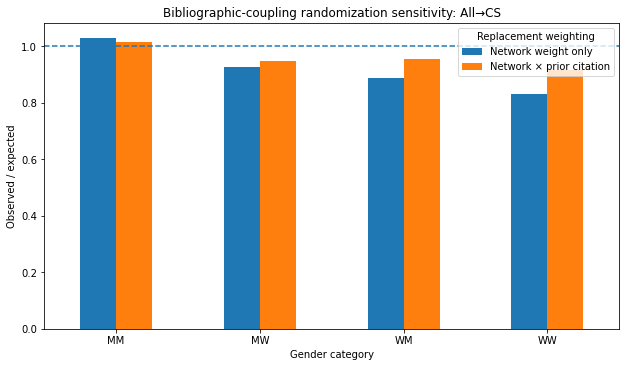

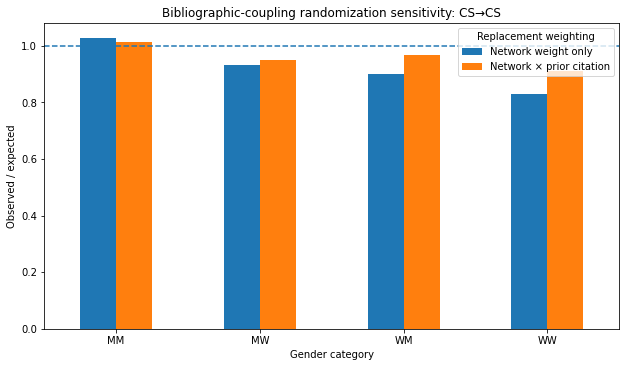

,Network weight only,Network × prior citation
gender_cat,,
MM,1.031252,1.014375
MW,0.926721,0.946559
WM,0.887275,0.956821
WW,0.832259,0.917218


,Network weight only,Network × prior citation
gender_cat,,
MM,1.029233,1.013372
MW,0.933549,0.948191
WM,0.898698,0.966085
WW,0.830115,0.912591


In [5]:
BC_VARIANT_LABELS = {
    "BC_network_weight_only": "Network weight only",
    "BC_network_x_prior_citation": "Network × prior citation",
}

def bc_prior_sensitivity_plot(citation_slice, filename):
    z = bc_prior[bc_prior["citation_slice"].eq(citation_slice)].copy()
    series = {}

    for baseline, label in BC_VARIANT_LABELS.items():
        q = z[z["baseline"].eq(baseline)].copy()
        q["gender_cat"] = pd.Categorical(
            q["gender_cat"],
            categories=GENDER_ORDER,
            ordered=True,
        )
        q = q.sort_values("gender_cat")
        series[label] = q.set_index("gender_cat")["oe_ratio"]

    plot_df = pd.DataFrame(series).reindex(GENDER_ORDER)

    ax = plot_df.plot(kind="bar", figsize=(8.8, 5.2))
    ax.axhline(1, linestyle="--")
    ax.set_xlabel("Gender category")
    ax.set_ylabel("Observed / expected")
    ax.set_title(
        f"Bibliographic-coupling randomization sensitivity: {citation_slice}"
    )
    ax.legend(title="Replacement weighting")
    plt.xticks(rotation=0)
    plt.tight_layout()

    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

    return plot_df

bc_prior_all = bc_prior_sensitivity_plot(
    "All→CS",
    "bc_randomization_prior_weighting_oe_all_to_cs.png",
)
bc_prior_cs = bc_prior_sensitivity_plot(
    "CS→CS",
    "bc_randomization_prior_weighting_oe_cs_to_cs.png",
)

display(bc_prior_all)
display(bc_prior_cs)